# Access ICESat-2 data in the Sierra Nevada for 2018 - 2021 using SlideRule Earth
* identify subregions of Sierra Nevada, since full domain is too large
* use SlideRule to access 3dep 10m resolution bare earth data, sampled at the ICESat-2 data points, as well as calculating slope and aspect at each of these points
* clip each subregion bounding box to outline of the Sierra Nevada as defined by the simplified GMBA polygon 
* merge subregions and years to form one dataframe with all points in Sierra Nevada for water years 2019 - 2021
* Save dataframe in pickle form for use in subsequent notebooks

NOTE: This study uses version 006 of the ICESat-2 data. It was originally accessed in October 2025, when that was the newest version available. NSIDC has since released version 007, which leads to small differences in the data. Version 006 data can still be accessed via SlideRule, but only when you specify the names of the granules you want to access. We have updated the access code here for the newest version of SlideRule, so we specify granule names though we did not need to when we originally accessed the data. The data we use is published in a Zenodo repository for reproducibility should version 006 be deprecated in the future. See other notebooks for a comparison of the data versions.

In [1]:
import re
from datetime import datetime

import pandas as pd
import geopandas as gpd
from sliderule import earthdata, icesat2, sliderule as sr

icesat2.init("slideruleearth.io", verbose=False)

True

In [2]:
# Load Sierra Nevada polygon
sierras_poly = gpd.read_file('../data/misc/sierra_simplified.geojson')

### Define three regions of the Sierra Nevada for easier data access

In [3]:
# Same three regions used throughout the original download
south_region = [
    {"lon": -120.2, "lat": 34.818611},
    {"lon": -117.862654, "lat": 34.818611},
    {"lon": -117.862654, "lat": 37.5},
    {"lon": -120.2, "lat": 37.5},
    {"lon": -120.2, "lat": 34.818611},
]
north_region_1 = [
    {"lon": -121.1, "lat": 37.5},
    {"lon": -118.5, "lat": 37.5},
    {"lon": -118.5, "lat": 39.0},
    {"lon": -121.1, "lat": 39.0},
    {"lon": -121.1, "lat": 37.5},
]
north_region_2 = [
    {"lon": -121.948903, "lat": 39.0},
    {"lon": -119.75, "lat": 39.0},
    {"lon": -119.75, "lat": 40.446988},
    {"lon": -121.948903, "lat": 40.446988},
    {"lon": -121.948903, "lat": 39.0},
]
regions = {"south": south_region, "north_1": north_region_1, "north_2": north_region_2}

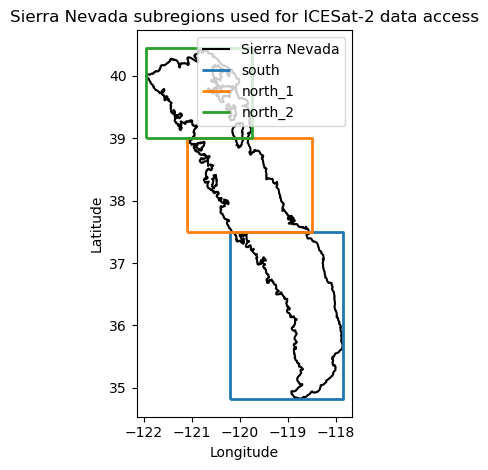

In [5]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

fig, ax = plt.subplots()

sierras_poly.boundary.plot(ax=ax, color="black", linewidth=1.5, label="Sierra Nevada")

region_colors = {"south": "tab:blue", "north_1": "tab:orange", "north_2": "tab:green"}
for name, region in regions.items():
    poly = Polygon([(pt["lon"], pt["lat"]) for pt in region])
    gpd.GeoSeries([poly], crs="EPSG:4326").boundary.plot(ax=ax, color=region_colors[name], linewidth=2, label=name)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sierra Nevada subregions used for ICESat-2 data access")
ax.legend()
plt.tight_layout()

### Set up the search for granule names
This is a workaround to access version 006 data using the newest version of SlideRule Earth, which defaults to version 007

In [ ]:
REV_CANDIDATES = ["01", "02", "03"]  # covers every case seen in spot-checks; a few granules
                                       # genuinely have no v006 release at all (real gaps, e.g. 2021-03-03 south pass)

In [ ]:
def granule_dt(g):
    return datetime.strptime(g.split("_")[1], "%Y%m%d%H%M%S")

t0_full = "2018-09-30T08:00:00Z"
t1_full = "2021-09-30T08:00:00Z"

granules_007_by_region = {}
for reg, region in regions.items():
    g = earthdata.cmr(short_name="ATL03", polygon=region, time_start=t0_full, time_end=t1_full)
    granules_007_by_region[reg] = sorted(g)
    print(f"{reg}: {len(g)} granules (007)")

south: 243 granules (007)
north_1: 260 granules (007)
north_2: 224 granules (007)


### Acess 006 version data, month by month for each region. 
I separate by month and by regions to avoid accessing too much data all at once, which in 2025 had caused some silent timeouts and therefore inconsistent numbers of points returned per try.

In [ ]:
# define a function to build the parameters for the SlideRule query, 
# and to supply granule names for 006 data access

def build_parms(region, t0, t1):
    return {
        "poly": region,
        "srt": icesat2.SRT_LAND,
        "cnf": icesat2.CNF_SURFACE_HIGH,
        "atl08_class": "atl08_ground",
        "ats": 10.0, "cnt": 10, "len": 40.0, "res": 20.0,
        "fit": {"maxi": 10},
        "atl08_fields": ["segment_snowcover", "segment_landcover", "beam_azimuth",
                         "segment_watermask", "urban_flag"],
        "samples": {"3dep": {"asset": "usgs3dep-10meter-dem",
                             "slope_aspect": True, "force_single_sample": True}},
        "t0": t0.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "t1": t1.strftime("%Y-%m-%dT%H:%M:%SZ"),
    }

def resources_for(granule_list):
    out = []
    for g in granule_list:
        base = re.sub(r"_007_\d{2}\.h5$", "", g)
        for rev in REV_CANDIDATES:
            out.append(f"{base}_006_{rev}.h5")
    return out

month_starts = pd.date_range("2018-10-01", "2021-09-01", freq="MS")
monthly_chunks = [
    (d.strftime("%Y-%m"), d.to_pydatetime(),
     (d + pd.offsets.MonthEnd(1) + pd.Timedelta(hours=23, minutes=59, seconds=59)).to_pydatetime())
    for d in month_starts
]
# NOTE: pd.offsets.MonthEnd(1) alone lands at midnight (00:00:00) of the last day of the month,
# which silently excludes any granule acquired later that day from BOTH this chunk and the next
# one (next month's t0 is the 1st at 00:00:00). Confirmed this dropped 4 real dates in the first
# run (e.g. ATL03_20190930183934_..., acquired 18:39 on the last day of Sept 2019) -- always
# push the month-end boundary to 23:59:59.
print(f"{len(monthly_chunks)} months x {len(regions)} regions = {len(monthly_chunks)*len(regions)} chunks")

36 months x 3 regions = 108 chunks


In [ ]:
# Run the data requests for each region and month, and collect the results into a single GeoDataFrame

# NOTE: this cell tries granule names with all possible 006 revision numbers, so there will be many
# messages about missing granules, but this might just mean a granule has a different revision number 
# than the one being tried. The first one found will be used for each granule.

all_gdfs = []
failed_chunks = []

for reg_label, region in regions.items():
    granules_007 = granules_007_by_region[reg_label]
    for month_label, t0, t1 in monthly_chunks:
        chunk_id = f"{reg_label}_{month_label}"
        month_granules = [g for g in granules_007 if t0 <= granule_dt(g) <= t1]
        if not month_granules:
            print(f"  {chunk_id}: no 007 granules found (skip)")
            continue
        resources = resources_for(month_granules)
        parms = build_parms(region, t0, t1)
        try:
            gdf = sr.run("atl03x", parms, resources=resources)
            if gdf is not None and len(gdf) > 0:
                gdf["_chunk"] = chunk_id
                all_gdfs.append(gdf)
                print(f"  {chunk_id}: {len(gdf)} points ({len(month_granules)} granules)")
            else:
                print(f"  {chunk_id}: empty result ({len(month_granules)} candidate granules)")
        except Exception as e:
            print(f"  {chunk_id}: FAILED - {e}")
            failed_chunks.append((reg_label, region, month_label, t0, t1, month_granules))

print(f"\nDone. {len(all_gdfs)} successful chunks, {len(failed_chunks)} failed.")

In [ ]:
# Any granules that failed in the first pass will be retried, in case the failure was due to a 
# transient network or server issue.

retry_still_failed = []
for reg_label, region, month_label, t0, t1, month_granules in failed_chunks:
    chunk_id = f"{reg_label}_{month_label}_retry"
    resources = resources_for(month_granules)
    parms = build_parms(region, t0, t1)
    try:
        gdf = sr.run("atl03x", parms, resources=resources)
        if gdf is not None and len(gdf) > 0:
            gdf["_chunk"] = chunk_id
            all_gdfs.append(gdf)
            print(f"  {chunk_id}: {len(gdf)} points (retry succeeded)")
        else:
            retry_still_failed.append(chunk_id)
            print(f"  {chunk_id}: empty on retry")
    except Exception as e:
        retry_still_failed.append(chunk_id)
        print(f"  {chunk_id}: FAILED again - {e}")

print(f"\nAfter retry: {len(retry_still_failed)} chunks still failed: {retry_still_failed}")

### Combine, clip, and sort into a single dataframe:

In [ ]:
sierras_006 = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=False))
sierras_006["time_acq"] = sierras_006.index

sierras_006_clip = sierras_006.clip(sierras_poly.to_crs(sierras_006.crs))
sierras_006_clip = sierras_006_clip.sort_values("time_acq")

print(f"Total points before clip: {len(sierras_006)}")
print(f"Total points after clip:  {len(sierras_006_clip)}")
sierras_006_clip

### Save to data folder, labeled with today's date:

In [ ]:
from datetime import date
today = date.today().strftime("%d%b%Y").lower()
out_path = f"../data/icesat2/sierras_gdf_2018_2021_006_reproduction_{today}.pkl"
sierras_006_clip.to_pickle(out_path)
print(f"Saved to {out_path}")

See notebook *process_sliderule_data.ipynb* for processing steps such as sampling reanalysis data and calculating snow depth